# 07 · Scale review — all four approaches, one board

The cross-approach comparison. The other notebooks each run **one** approach; this one *reviews many at once*. Point it at the `run_id`s you already ran — one per approach (`spark-explode`, `spark-multi`, `spark-naive`, `ray`) — and it renders them side by side: the **scaling-and-efficiency** story from `v_run_summary` (wall-clock, provisioning overhead, DCU) and the **accuracy** story from `v_model_leaderboard` (which model won, and how fast it fit).

It **runs nothing** — no config, no `main.run`. It only reads the registry views, so it's cheap and re-runnable while the CLI-submitted 100k runs finish. Because every approach is now **one `run_id` each** (post-C3, including `multi`), the join is a clean one-row-per-approach comparison.

## Get the code (cloud runtimes only)

On a cloud notebook (Colab Enterprise, Vertex Workbench) this clones or updates the repo so you're on the latest `src/`. **Skip it in a local clone** — it's a no-op guarded on the package already being importable.

In [1]:
# Cloud bootstrap: clone + editable-install so `import scale_forecasting` resolves.
# Harmless locally — if the package already imports, we do nothing.
import importlib.util
import os
import subprocess
import sys

REPO_URL = os.environ.get("SF_REPO_URL", "https://github.com/statmike/scale-forecasting.git")
REPO_DIR = os.environ.get("SF_REPO_DIR", "scale-forecasting")

if importlib.util.find_spec("scale_forecasting") is None:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-e", REPO_DIR], check=True)
    sys.path.insert(0, os.path.join(REPO_DIR, "src"))

## Resolve the deployment (live GCP)

`Settings.resolve()` reads the `SF_*` environment — the *same* identity every writer uses (G1). Required: `SF_PROJECT_ID`, `SF_CONNECTION`, `SF_WAREHOUSE_URI`; `SF_DATASET_ID`/`SF_REGION` default. This notebook only *reads* the `v_run_summary` / `v_model_leaderboard` views.

In [2]:
from google.cloud import bigquery

from scale_forecasting.settings import Settings

settings = Settings.resolve()
client = bigquery.Client(project=settings.project_id)
DATASET = settings.dataset_ref
print("deployment:", DATASET, "region:", settings.region)

deployment: statmike-scale-forecasting.scale_forecasting region: us-central1


## Parameters — the four run_ids to compare

Fill in **one `run_id` per approach** — the ids printed by the four CLI-submitted 100k runs (or the notebook demos at any scale). The keys are the official method names; leave a value `None` to skip that approach (the review just omits it).

> Every value is one `run_id` because all four approaches are one-run-each — `multi` included, post-C3. `spark_method` in `v_run_summary` still records *how* each ran, so the comparison stays honest about the fan-out.

Find recent ids with the discovery cell below if you don't have them handy.

In [3]:
# === Parameters — edit me ===============================================
# One run_id per approach (None → skip). Official method names as keys.
RUN_IDS = {
    "spark-explode": "explode-100k-99549c4d2164",
    "spark-multi": "multi-100k-3f3c4141823c",
    "spark-naive": "naive-100k-187e1027858c",
    "ray": "ray-100k-74938424d463",
}
# ========================================================================

approaches = {name: rid for name, rid in RUN_IDS.items() if rid}
print("comparing", len(approaches), "approach(es):")
for name, rid in approaches.items():
    print(f"  {name:<14} {rid}")

comparing 4 approach(es):
  spark-explode  explode-100k-99549c4d2164
  spark-multi    multi-100k-3f3c4141823c
  spark-naive    naive-100k-187e1027858c
  ray            ray-100k-74938424d463


## (Optional) Discover recent run_ids

Don't have the ids? This lists the most recent completed runs with their `spark_method` / `python_runtime` and scale, so you can copy the right `run_id` into the cell above. Purely a convenience — skip it if you already pasted them.

In [4]:
import pandas as pd

recent = client.query(
    f"SELECT run_id, created_at, status, spark_method, python_runtime, n_series, n_models "
    f"FROM `{DATASET}.v_run_summary` "
    f"ORDER BY created_at DESC LIMIT 25"
).result().to_dataframe()
recent

,run_id,created_at,status,spark_method,python_runtime,n_series,n_models
0,ray-100k-74938424d463,2026-08-09 05:26:14.924098+00:00,COMPLETED,None,ray,100000,4
1,ray-100k-5c5b8c3c1a78,2026-08-09 04:55:05.928677+00:00,RUNNING,None,ray,100000,4
2,ray-100k-d8c3fdf02d2d,2026-08-08 21:59:32.016939+00:00,RUNNING,None,ray,100000,4
3,ray-100k-d8c3fdf02d2d,2026-08-08 21:37:22.294179+00:00,RUNNING,None,ray,100000,4
4,ray-100k-d8c3fdf02d2d,2026-08-08 20:57:57.541617+00:00,RUNNING,None,ray,100000,4
5,naive-100k-187e1027858c,2026-08-08 20:22:17.012491+00:00,COMPLETED,naive,spark,100000,4
6,naive-100k-7530d9b41ebb,2026-08-08 15:06:09.193349+00:00,RUNNING,naive,spark,100000,4
7,multi-100k-3f3c4141823c,2026-08-08 15:01:25.842892+00:00,COMPLETED,multi,spark,100000,4
8,explode-100k-99549c4d2164,2026-08-08 13:50:20.055080+00:00,COMPLETED,explode,spark,100000,4
9,explode-100k-99549c4d2164,2026-08-08 12:57:10.070937+00:00,COMPLETED,explode,spark,100000,4


## Scaling + efficiency — `v_run_summary`, one row per approach

The whole efficiency story in one table: `runtime_seconds` (the engine's own compute), `total_wall_s` (including cluster stand-up), `overhead_seconds` / `overhead_fraction` (provisioning tax — amortizes as `n_series` grows), and `dcu_milli_seconds` (the Dataproc cost proxy). Labeled by approach and ordered so the fan-out methods line up against each other.

In [5]:
def summaries(approaches):
    """One v_run_summary row per approach, labeled with the approach name."""
    frames = []
    for name, rid in approaches.items():
        df = client.query(
            f"SELECT * FROM `{DATASET}.v_run_summary` WHERE run_id=@run_id",
            job_config=bigquery.QueryJobConfig(
                query_parameters=[bigquery.ScalarQueryParameter("run_id", "STRING", rid)]
            ),
        ).result().to_dataframe()
        df.insert(0, "approach", name)
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


summary = summaries(approaches)
summary

,approach,run_id,created_at,status,spark_method,python_runtime,n_series,n_models,backtest_on,runtime_seconds,total_wall_s,overhead_seconds,overhead_fraction,executor_instances,executor_cores,max_executors,dcu_milli_seconds,runtime_version
0,spark-explode,explode-100k-99549c4d2164,2026-08-07 13:02:15.757792+00:00,COMPLETED,explode,spark,100000,4,False,4146.796997,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,None
1,spark-explode,explode-100k-99549c4d2164,2026-08-08 12:57:10.070937+00:00,COMPLETED,explode,spark,100000,4,False,4146.796997,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,None
2,spark-explode,explode-100k-99549c4d2164,2026-08-08 13:50:20.055080+00:00,COMPLETED,explode,spark,100000,4,False,4146.796997,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,None
3,spark-explode,explode-100k-99549c4d2164,2026-08-08 02:18:36.272250+00:00,COMPLETED,explode,spark,100000,4,False,4146.796997,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,None
4,spark-multi,multi-100k-3f3c4141823c,2026-08-08 15:01:25.842892+00:00,COMPLETED,multi,spark,100000,4,False,12.543278,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,None
5,spark-naive,naive-100k-187e1027858c,2026-08-08 20:22:17.012491+00:00,COMPLETED,naive,spark,100000,4,False,6532.563132,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,None
6,ray,ray-100k-74938424d463,2026-08-09 05:26:14.924098+00:00,COMPLETED,None,ray,100000,4,False,6414.603041,6685.5,270.896959,0.04052,<NA>,<NA>,<NA>,<NA>,None


## The showpiece — compute vs provisioning overhead, per approach

A stacked bar per approach: `runtime_seconds` (real forecasting work) plus `overhead_seconds` (cluster stand-up) = `total_wall_s`. At 100k series the compute bar should dominate every approach, and `explode` should finish in roughly its slowest *cell* while `naive` drags on its slowest *series* — the anti-pattern, visible as wall-clock.

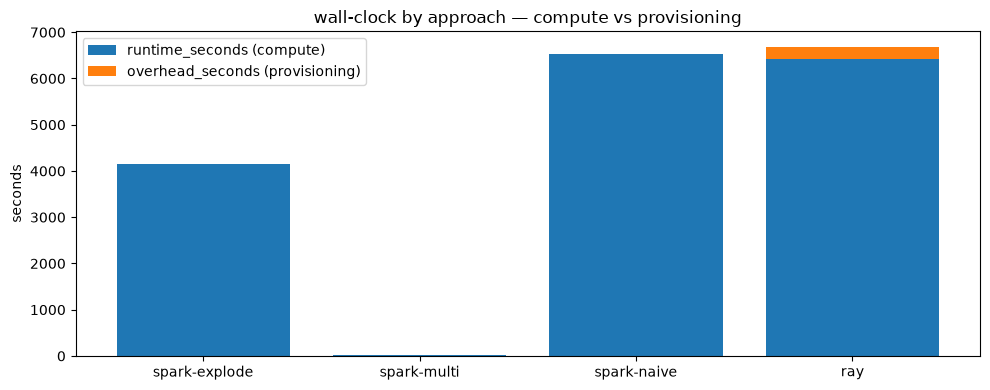

In [6]:
import matplotlib.pyplot as plt

if not summary.empty:
    plot_df = summary.fillna({"runtime_seconds": 0, "overhead_seconds": 0})
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(plot_df["approach"], plot_df["runtime_seconds"], label="runtime_seconds (compute)",
           color="#1f77b4")
    ax.bar(plot_df["approach"], plot_df["overhead_seconds"], bottom=plot_df["runtime_seconds"],
           label="overhead_seconds (provisioning)", color="#ff7f0e")
    ax.set_ylabel("seconds")
    ax.set_title("wall-clock by approach — compute vs provisioning")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No run_ids set — fill in RUN_IDS above.")

## Accuracy — every model, every approach, one leaderboard

All approaches' `v_model_leaderboard` rows stacked, labeled by approach. `worker.run_cell` is identical across engines (G1), so a model's `mean_wape` should be consistent whether it ran under `explode`, `multi`, `naive`, or `ray` — the fan-out changes *speed*, not *answers*. Any drift here is a signal, not a feature. `median_fit_seconds` still exposes the straggler under `naive`.

In [7]:
def leaderboards(approaches):
    """Stack every approach's v_model_leaderboard rows, labeled by approach."""
    frames = []
    for name, rid in approaches.items():
        df = client.query(
            f"SELECT model_type, compute_engine, n_cells, no_artifact_rate, "
            f"median_fit_seconds, mean_wape, mean_mae "
            f"FROM `{DATASET}.v_model_leaderboard` WHERE run_id=@run_id",
            job_config=bigquery.QueryJobConfig(
                query_parameters=[bigquery.ScalarQueryParameter("run_id", "STRING", rid)]
            ),
        ).result().to_dataframe()
        df.insert(0, "approach", name)
        frames.append(df)
    out = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    return out.sort_values(["model_type", "approach"]) if not out.empty else out


board = leaderboards(approaches)
board

,approach,model_type,compute_engine,n_cells,no_artifact_rate,median_fit_seconds,mean_wape,mean_mae
12,ray,holtwinters,ray,100000,1.0,0.542463,NaN,NaN
1,spark-explode,holtwinters,spark,305755,1.0,0.444774,NaN,NaN
6,spark-multi,holtwinters,spark,100000,1.0,0.466462,NaN,NaN
9,spark-naive,holtwinters,spark,100000,1.0,0.370374,NaN,NaN
15,ray,sarimax,ray,100000,1.0,2.383579,NaN,NaN
2,spark-explode,sarimax,spark,305055,1.0,2.825462,NaN,NaN
5,spark-multi,sarimax,spark,100000,1.0,2.969840,NaN,NaN
10,spark-naive,sarimax,spark,100000,1.0,2.198463,NaN,NaN
13,ray,theta,ray,100000,1.0,0.536850,NaN,NaN
0,spark-explode,theta,spark,305414,1.0,0.606077,NaN,NaN


## Same model, same answer — accuracy parity across engines (G1)

`mean_wape` for each model, grouped by approach. Bars for the *same* model should sit at nearly the same height across approaches — the visual proof that the fan-out method is an execution detail, not a modeling one. (Models that only exist under one engine, e.g. the BigQuery natives, appear once.)

In [8]:
if board.empty:
    print("No leaderboard rows — fill in RUN_IDS above.")
elif board["mean_wape"].notna().any():
    pivot = board.pivot_table(index="model_type", columns="approach", values="mean_wape")
    ax = pivot.plot(kind="bar", figsize=(11, 4))
    ax.set_ylabel("mean WAPE (lower is better)")
    ax.set_title("same model, same answer — mean_wape by approach")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()
else:
    # mean_wape is populated only when a backtest ran; the 100k scale runs turn backtest OFF for
    # speed, so every mean_wape is NULL and there is nothing to plot. Expected at scale — the
    # scaling/efficiency panels above are the showpiece; accuracy parity is a small-scale story
    # (turn backtest on in a demo config to populate it). See docs/output_schemas.md.
    print("mean_wape is all-NULL for these runs (backtest off — the 100k default).")
    print("Nothing to plot; see the scaling + efficiency panels above.")


mean_wape is all-NULL for these runs (backtest off — the 100k default).
Nothing to plot; see the scaling + efficiency panels above.
